In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve)
import joblib

In [4]:
df = pd.read_csv('cleaned_data.csv')
print(f"Shape: {df.shape}")
df.head(5)

Shape: (7487, 24)


,Order_ID,Product_ID,User_ID,Order_Date,Return_Date,Product_Category,Product_Price,Order_Quantity,Return_Reason,Return_Status,...,Payment_Method,Shipping_Method,Discount_Applied,signal_changed_mind,signal_high_discount,signal_late_return,signal_bulk_return,signal_expensive_item,abuse_score,is_abuse
0,ORD00000000,PROD00000000,USER00000000,2023-08-05,2024-08-26 00:00:00,Clothing,411.59,3,Changed mind,Returned,...,Debit Card,Next-Day,45.27,1,1,1,0,1,4,1
1,ORD00000001,PROD00000001,USER00000001,2023-10-09,2023-11-09 00:00:00,Books,288.88,3,Wrong item,Returned,...,Credit Card,Express,47.79,0,1,0,0,0,1,0
2,ORD00000002,PROD00000002,USER00000002,2023-05-06,NaN,Toys,390.03,5,Not Returned,Not Returned,...,Debit Card,Next-Day,26.64,0,0,0,0,0,0,0
3,ORD00000003,PROD00000003,USER00000003,2024-08-29,NaN,Toys,401.09,3,Not Returned,Not Returned,...,PayPal,Next-Day,15.37,0,0,0,0,0,0,0
4,ORD00000004,PROD00000004,USER00000004,2023-01-16,NaN,Books,110.09,4,Not Returned,Not Returned,...,Gift Card,Standard,16.37,0,0,0,0,0,0,0


In [5]:
FEATURE_COLS = [
    'signal_changed_mind',
    'signal_high_discount',
    'signal_late_return',
    'signal_bulk_return',
    'signal_expensive_item',
    'abuse_score',
    'Product_Price',
    'Discount_Applied',
    'Order_Quantity',
    'Days_to_Return',
    'User_Age'
]

TARGET = 'is_abuse'

X = df[FEATURE_COLS]
y = df[TARGET]

print(f"Features: {X.shape}")
print(f"Target distribution:\n{y.value_counts()}")

Features: (7487, 11)
Target distribution:
is_abuse
0    5725
1    1762
Name: count, dtype: int64


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 80% train, 20% test
    random_state=42,     # reproducible results
    stratify=y           # keep same abuse ratio in both splits
)

print(f"Train size: {len(X_train)}")
print(f"Test size:  {len(X_test)}")

Train size: 5989
Test size:  1498


In [7]:
rf_model = RandomForestClassifier(
    n_estimators=100,    # 100 decision trees
    max_depth=10,        # prevent overfitting
    random_state=42,
    class_weight='balanced'  # handles the 76/24 class imbalance
)

rf_model.fit(X_train, y_train)
print("Model trained!")

Model trained!


In [8]:
y_pred      = rf_model.predict(X_test)
y_pred_prob = rf_model.predict_proba(X_test)[:, 1]

print("--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Not Abuse', 'Abuse']))

print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_prob):.4f}")

--- Classification Report ---
              precision    recall  f1-score   support

   Not Abuse       1.00      1.00      1.00      1145
       Abuse       1.00      1.00      1.00       353

    accuracy                           1.00      1498
   macro avg       1.00      1.00      1.00      1498
weighted avg       1.00      1.00      1.00      1498

ROC-AUC Score: 1.0000


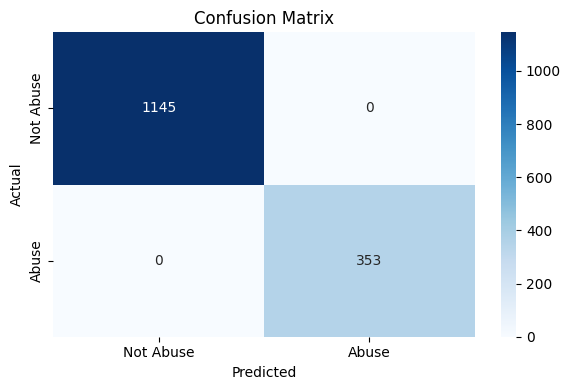

In [9]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Abuse', 'Abuse'],
            yticklabels=['Not Abuse', 'Abuse'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

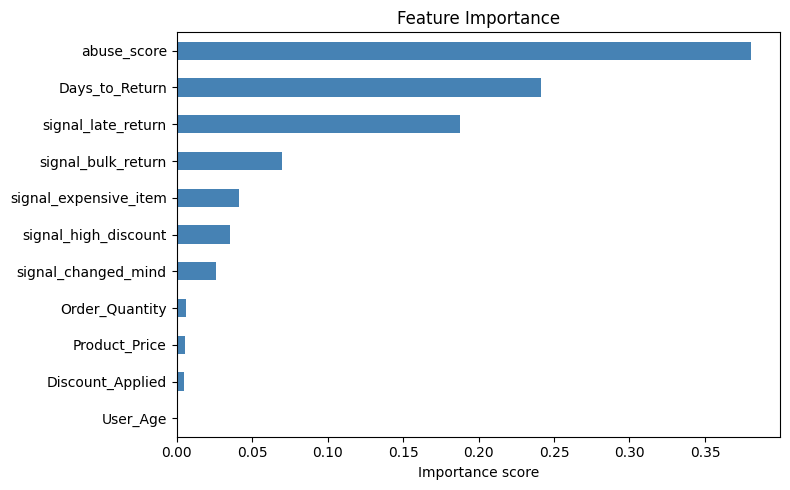

In [10]:
importances = pd.Series(rf_model.feature_importances_, index=FEATURE_COLS)
importances = importances.sort_values(ascending=True)

importances.plot(kind='barh', figsize=(8, 5), color='steelblue')
plt.title('Feature Importance')
plt.xlabel('Importance score')
plt.tight_layout()
plt.show()

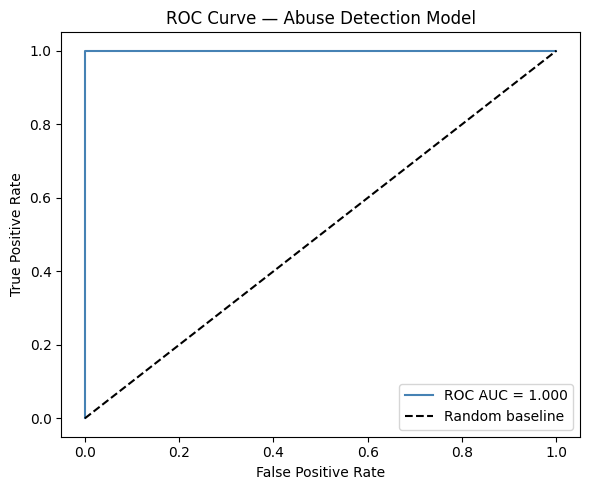

In [11]:
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
auc = roc_auc_score(y_test, y_pred_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='steelblue', label=f'ROC AUC = {auc:.3f}')
plt.plot([0,1], [0,1], 'k--', label='Random baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Abuse Detection Model')
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
# Simulate one order record coming in
sample = pd.DataFrame([{
    'signal_changed_mind':   1,
    'signal_high_discount':  1,
    'signal_late_return':    0,
    'signal_bulk_return':    0,
    'signal_expensive_item': 1,
    'abuse_score':           3,
    'Product_Price':         420.0,
    'Discount_Applied':      40.0,
    'Order_Quantity':        2,
    'Days_to_Return':        15.0,
    'User_Age':              34
}])

prediction   = rf_model.predict(sample)[0]
probability  = rf_model.predict_proba(sample)[0][1]

print(f"Prediction:  {'ABUSE' if prediction == 1 else 'NOT ABUSE'}")
print(f"Probability: {probability:.2%}")

Prediction:  ABUSE
Probability: 100.00%


In [14]:
joblib.dump(rf_model, 'rf_model.pkl')
print("Model saved as rf_model.pkl")

Model saved as rf_model.pkl
